# Attempted mechanistic model

In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize

import optimization_engine as oe
from optimization_engine import (
    loss_joint, run_model_stim, JOINT_BOUNDS, PARAM_NAMES,
)
from vivo_target import load_vivo_psth
from diagnose_mechanistic import diagnose

# Real in-vivo population PSTH = single source of truth for BOTH the loss and
# the diagnostic plots (replaces the old hand-drawn RULE caricature targets).
bins_plot, mean_vivo_rate, mean_vivo_smooth = load_vivo_psth()
vivo = (bins_plot, mean_vivo_rate, mean_vivo_smooth)
print(f"vivo PSTH: {len(bins_plot)} bins, FR {mean_vivo_rate.min():.0f}..{mean_vivo_rate.max():.0f} Hz")
print("Joint search dims:", len(JOINT_BOUNDS), "(10 geometry + 20 stim/channel)")


In [2]:
# Geometry pulled from the engine (don't redefine bounds locally — they live in
# optimization_engine.py so the loss and the notebook can never drift apart).
N = oe.N
THETA = oe.THETA
T_END = oe.T_END


## The model — full equations

A **linear ring attractor** (`N=120` excitatory cells at preferred dirs $\theta_i$ + a co-tuned interneuron ring) with intrinsic thalamic currents. Both evoked drives (FC, SC) arrive as **spatially GLOBAL / untuned** inputs; the SC's PD-tuning **emerges** from a network bump-gate. $u$ = membrane variable, $r$ = rate (Hz), $\Delta t=0.2$ ms, $\sigma(x)=1/(1+e^{-x})$.

**Threshold-linear gain** (a supralinear SSN gain was tried — good for gating but it makes the low-rate late state fragile, bump collapses ~700 ms — so linear):
$$r_E = f(u) = \min\!\big(R_{\max},\ \text{GAIN\_SLOPE}\cdot[u]_+\big),\qquad [u]_+=\max(0,u)$$

**Ring connectivity** — narrow excitation ($\kappa_E$) minus broad inhibition ($\kappa_I<\kappa_E$) = Mexican-hat:
$$K^E_{ij}=\tfrac1N e^{\kappa_E(\cos\Delta\theta_{ij}-1)},\qquad K^I_{ij}=\tfrac1N e^{\kappa_I(\cos\Delta\theta_{ij}-1)},\qquad \Delta\theta_{ij}=\theta_i-\theta_j$$

**Network dynamics:**
$$\tau_E\,\dot u^E_i = -u^E_i + \underbrace{J_1(K^E r_E)_i}_{\text{recurrent exc}} - \underbrace{W_{IE}(K^I r_I)_i}_{\text{tuned inh}} - \underbrace{W_{\text{glob}}\,\bar r_E}_{\substack{\text{global inh}\\ \text{(stabilizer)}}} + I^{\text{ext}}_i + I^{SC}_i + I^T_i + I^h_i - \underbrace{g_a\,a}_{\substack{\text{adaptation}\\ \text{(width recovery)}}}$$
$$\tau_I\,\dot u^I_i = -u^I_i + W_{EI}(K^E r_E)_i,\qquad r_I=[u^I]_+,\qquad \bar r_E=\tfrac1N\textstyle\sum_j r_{E,j}$$
$u^E$ floored (at `reversal_potential` during stim, else $-100$), not clamped above.

**Inputs.** Tonic tuned HD drive (the *only* tuned input, $h_i=e^{\kappa_{HD}(\cos\theta_i-1)}$) + a brief **global** FC volley; onset $t_0=$ `stim_delay`:
$$I^{\text{ext}}_i = I_{\text{base}} + I_{HD}\,h_i + A_{\text{fast}}\;\mathbb{1}[\,t_0\le t< t_0+\Delta_{fc}\,]$$

**Global SC input × bump-gate (emergent tuning).** A **spatially UNIFORM** double-exponential drive, gated by a **low-passed** bump-membership signal (memory $\tau_{scg}$), $\Delta t=t-(t_0+\text{sc\_delay})$:
$$\tau_{scg}\dot\ell_i = \text{rec}_i-\ell_i,\quad \text{sc\_gate}_i=\frac{\ell_i}{\ell_i+\text{REC}_{1/2}},\quad I^{SC}_i = A_{sc}\big(e^{-\Delta t/\tau^{\text{off}}_{sc}}-e^{-\Delta t/\tau^{\text{on}}_{sc}}\big)\,\text{sc\_gate}_i,\quad \text{rec}_i=J_1(K^E r_E)_i$$
Bump cells ($\text{rec}_i$ high) get the SC → PD rises to ~91 Hz; the antipode ($\text{rec}_i\approx0\Rightarrow\text{sc\_gate}\approx0$) gets ≈nothing → **anti-PD silent**, though the *input* is global. The memory $\tau_{scg}$ (~30 ms) bridges the dip so the gate doesn't slam shut and re-open as a spike ⇒ smooth SC onset.

**I_T (T-type Ca²⁺)** — post-inhibitory rebound *shaping*, recurrent-gated:
$$m_T=\sigma\!\Big(\tfrac{u-V^T_{1/2}}{k_T}\Big),\ h_{T\infty}=\sigma\!\Big(\!-\tfrac{u-V^T_{1/2}}{k_T}\Big),\ \tau_{hT}\dot h_T = h_{T\infty}-h_T,\ I^T = g_T m_T h_T (E_{Ca}-u)\tfrac{\text{rec}_i}{\text{rec}_i+\text{REC}_{1/2}}$$

**I_h (HCN)** — slow depolarizing tail, additive, asymmetric kinetics ($k_h=$ `K_H_SLOPE`):
$$m_{h\infty}=\sigma\!\Big(\!-\tfrac{u-V^h_{1/2}}{k_h}\Big),\ \tau_h=\begin{cases}\tau_{h,\text{on}}&m_{h\infty}>m_h\\ \tau_{h,\text{off}}&\text{else}\end{cases},\ \tau_h\dot m_h=m_{h\infty}-m_h,\ I^h=g_h m_h$$

**Global slow adaptation (SK / M-current)** — mean-field, the load-bearing **width-recovery**:
$$\tau_a\,\dot a = \bar r_E - a,\qquad I_{\text{adapt}} = g_a\,a\quad(\text{uniform})$$

$I^{SC},\,I^T,\,I^h$, the gate memory and adaptation are all **gated off** before $t_0$.

---

**Key result (emergence).** A *tall, recovering* SC cannot **self-amplify** from recurrence in one ring (bistable latch / drift — proven for supralinear gain, intrinsic channels, and short-term facilitation). The resolution keeps every input **untuned**: the SC arrives as a global drive and the **bump-gate** produces the tuned, PD-selective SC *output* — the SC is an *ADN output*, not a tuned input. Ablations: $A_{sc}=0$ collapses the SC (88→55 Hz); $g_a=0$ leaves the bump stuck broad (FWHM ~93 vs ~63°); anti-PD stays 0. Final: **R² ≈ 0.92** on [-50, 700] ms (a spatially-tuned-SC version reached 0.945; the ~0.03 buys emergent tuning).

In [ ]:
# SINGLE-STAGE JOINT FIT (all 30 params at once): 10 geometry (incl. upstream HD
# drive I_HD + global inhibition W_GLOBAL) + 20 stim/channel (FC, dip, I_T, I_h,
# global ADAPTATION g_a/tau_a, and the GLOBAL SC input A_sc + its bump-gate memory
# tau_scg -> the tuned SC OUTPUT emerges from the gate, no tuned input).
# NB: loss_joint is NOT R2-aligned and the valid (recovering) basin is narrow, so
# plain DE under-shoots (~0.6). The saved best (R2~0.92) came from a direct
# R2-search (_run_full_fit.py + _polish_stf.py) -> prefer loading it (cell below).
res = differential_evolution(
    loss_joint,
    JOINT_BOUNDS,
    args=(bins_plot, mean_vivo_rate, mean_vivo_smooth),
    seed=42,
    maxiter=400,
    popsize=18,
    tol=1e-6,
    init='sobol',
    mutation=(0.7, 1.9),
    recombination=0.5,
    polish=True,
    disp=True,
    workers=-1,
)
res = minimize(loss_joint, x0=res.x, bounds=JOINT_BOUNDS,
               args=(bins_plot, mean_vivo_rate, mean_vivo_smooth),
               method='L-BFGS-B', options={'maxiter': 400})

params = list(res.x)
stage1_frozen = dict(zip(PARAM_NAMES[:10], params[:10]))
stage2_params = params[10:]
print(f"\nJoint loss = {res.fun:.1f}")
for k, v in zip(PARAM_NAMES, params):
    print(f"  {k:18s} {v:.3f}")


In [4]:
# OPTIONAL: skip the ~8-min DE above and load the last saved best fit instead
# (written by _run_full_fit.py / the joint cell). Handy for tweaking plots.
import json, pathlib
_p = pathlib.Path("_full_fit_result.json")
if _p.exists():
    saved = json.load(open(_p))["params"]
    params = [saved[k] for k in PARAM_NAMES]
    stage1_frozen = dict(zip(PARAM_NAMES[:10], params[:10]))
    stage2_params = params[10:]
    print("Loaded saved params. R2 was", round(json.load(open(_p)).get("r2", float('nan')), 3))
else:
    print("No saved fit; run the joint cell above.")


Loaded saved params. R2 was 0.945


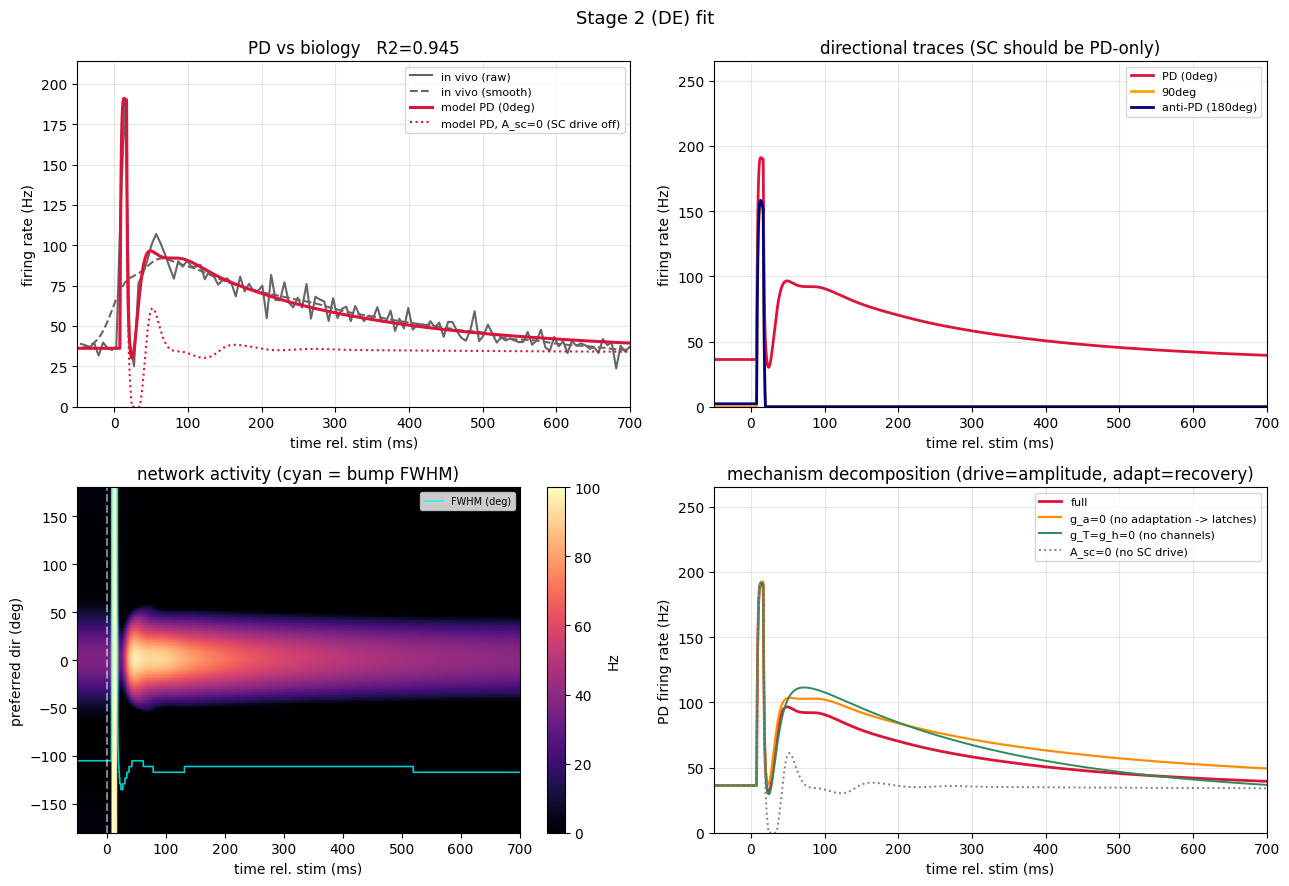

PD fit R2 = 0.945
SC-window PD max: full 96.5 Hz | A_sc=0 61.0 Hz
SC-window anti-PD max: 0.0 Hz (should be near baseline)
recovery: PD 42.1 Hz @500-700 (baseline ~37; should return)


np.float64(0.9449462123924997)

In [5]:
# Full diagnostic: PD vs real PSTH (with ablation), directional traces,
# heatmap, and I_T/I_h channel decomposition.
diagnose(stage1_frozen, stage2_params, vivo=vivo, title="Stage 2 (DE) fit", t_hi=700)

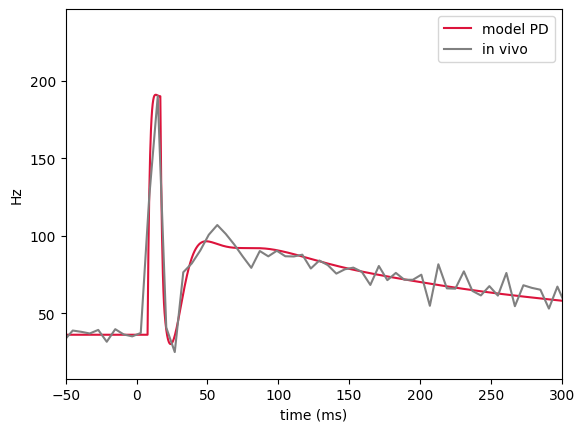

In [6]:
# Quick single-trace inspection (PD cell) if you want it raw.
t_model, rates = run_model_stim(
    *[stage1_frozen[k] for k in PARAM_NAMES[:10]], *stage2_params
)
plt.plot(t_model, rates[:, oe._IDX_0], color="crimson", label="model PD")
plt.plot(bins_plot, mean_vivo_rate, color="0.5", label="in vivo")
plt.xlim(-50, 300); plt.xlabel("time (ms)"); plt.ylabel("Hz"); plt.legend(); plt.show()

### Local polish + final mechanistic fit
L-BFGS-B refines the DE winner; then re-run the full diagnostic. Watch the **ablation** (dotted) and **anti-PD** (navy) traces — they are the evidence the SC is mechanistic and PD-only.

In [ ]:
# Verification summary: the mechanistic checks (not just R2).
t, r = run_model_stim(*[stage1_frozen[k] for k in PARAM_NAMES[:10]], *stage2_params)
pd, anti = r[:, oe._IDX_0], r[:, oe._IDX_180]
s1 = [stage1_frozen[k] for k in PARAM_NAMES[:10]]
# ablations (indices WITHIN the stage-2 vector, PARAM_NAMES[10:]):
#   A_sc idx 15 -> GLOBAL SC input (its bump-gated output is the SC hump)
#   g_a  idx 13 -> global adaptation (drives WIDTH recovery)
no_drive = list(stage2_params); no_drive[15] = 0.0
no_adapt = list(stage2_params); no_adapt[13] = 0.0
_, r_nd = run_model_stim(*s1, *no_drive)
_, r_na = run_model_stim(*s1, *no_adapt)
m = (t > 40) & (t < 300)
_, ri = oe.run_model_idle(*s1)
prof = ri[-1, :]; pk = prof.max()
def fwhm(p): return (p >= p.max()/2).sum() * 360.0 / oe.N
def at(a, tt): return a[np.argmin(np.abs(t-tt))]
prof6 = r[np.argmin(np.abs(t-600)), :]
print(f"baseline bump peak    : {pk:.0f} Hz  (target ~40), FWHM {fwhm(prof):.0f} deg")
print(f"baseline secondary    : {100*prof[oe.OFF_LOBE].max()/max(pk,.01):.1f}% of peak  (want ~0)")
print(f"FC peak               : {pd[(t>=stage2_params[2])&(t<stage2_params[2]+12)].max():.0f} Hz  (data ~170)")
print(f"SC peak (PD)          : {pd[m].max():.0f} Hz @ {t[m][pd[m].argmax()]:.0f} ms  (data ~91 @ ~55)")
print(f"SC, input off (A_sc=0): {r_nd[:,oe._IDX_0][m].max():.0f} Hz  -> input supplies {100*(1-r_nd[:,oe._IDX_0][m].max()/max(pd[m].max(),.01)):.0f}% of SC")
print(f"anti-PD SC max        : {anti[m].max():.1f} Hz  (want ~0; tuning is EMERGENT, input is global)")
print(f"RECOVERY @600ms       : PD {at(pd,600):.0f} Hz, FWHM {fwhm(prof6):.0f} deg  (baseline {pk:.0f}/{fwhm(prof):.0f})")
print(f"  no adaptation g_a=0 : FWHM @600 {fwhm(r_na[np.argmin(np.abs(t-600)),:]):.0f} deg  -> stays broad (no width recovery)")
print(f"I_HD={stage1_frozen['I_HD']:.1f}  W_GLOBAL={stage1_frozen['W_GLOBAL']:.1f}  "
      f"g_a={stage2_params[13]:.2f}  A_sc={stage2_params[15]:.1f}  tau_scg={stage2_params[19]:.0f}")


In [ ]:
# Final fit — full diagnostic + emergence/recovery evidence (window to 700 ms).
r2 = diagnose(stage1_frozen, stage2_params, vivo=vivo, t_hi=700,
              title="Final fit — global SC input x bump-gate (emergent tuning, recovers)")
